# Training the VAE
I train a VAE so that it produces the type of maximum degraded images that the Cold Diffusion expects.

ref: https://github.com/AntixK/PyTorch-VAE

I train the VanillaVAE on the same dataset used for training the Cold Diffusion models, so that the VAE learn the distribution of that type of images (human faces).

## Architecture
The VanillaVAE has 5 default layers, with conv stride = 2 in the encoder. It expects 64x64 input. In the bottleneck, the input has dimensions: (-1, 512, 2, 2). In this notebook instead, I use 3 layers instead of 5, 16x16 input. The encoder does: 16->8->4->2, reaching the same dimension as in the original implementation: 2x2. This also allows to not modify the original decode() function, which has (512, 2, 2) dimension. I modified PATCH_SIZE accordingly.

In [ ]:
TRAIN = False

In [ ]:
import os
import sys
import glob
import time
import torch
from torch import optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# CONFIG
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/tesi/" if 'google.colab' in str(get_ipython()) else "."
PYTORCH_VAE_REPO = os.path.join(BASE_DIR, 'src/PyTorch-VAE-master')
ZIP_PATH = os.path.join(BASE_DIR, "data", "img_align_celeba.zip")
SAVE_PATH = os.path.join(BASE_DIR, 'trained_models', 'vae', 'vae_blur_checkpoint_16x16.pt')

LOCAL_DATA_ROOT = "/content/raw_data"

HIDDEN_DIMS = [128, 256, 512]   # must end in 512, explanation above
LATENT_DIM = 64              # smaller than default to avoid overfit
PATCH_SIZE = 16               # = 2 * 2**len(HIDDEN_DIMS)
BATCH_SIZE = 64
LR = 0.005
WEIGHT_DECAY = 0.0
SCHEDULER_GAMMA = 0.95
KLD_WEIGHT = 0.00025         # from original code
RESUME = True                  # checkpoint
ADDITIONAL_EPOCHS = 2.5        # additional epochs with respect to last checkpoint
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
LOG_EVERY = 50
CHECKPOINT_EVERY_STEPS = 300

In [ ]:
if not os.path.exists(LOCAL_DATA_ROOT):
    print("Unzipping ...")
    !unzip -q "{ZIP_PATH}" -d {LOCAL_DATA_ROOT}
    print("Done!")
else:
    print("Already unzipped")


dataset_path = os.path.join(LOCAL_DATA_ROOT, "img_align_celeba")
print(f"Dataset path: {dataset_path}")

Already unzipped
Dataset path: /content/raw_data/img_align_celeba


In [ ]:
assert HIDDEN_DIMS[-1] == 512, "hidden_dims must end with 512"
assert PATCH_SIZE == 2 * 2 ** len(HIDDEN_DIMS), \
    f"PATCH_SIZE must be {2 * 2 ** len(HIDDEN_DIMS)} with {len(HIDDEN_DIMS)} layers, not {PATCH_SIZE}"

sys.path.append(PYTORCH_VAE_REPO)
from models.vanilla_vae import VanillaVAE


class FaceFolderDataset(Dataset):
    """
    The dataset does not need big preprocessing, just resizing
    """

    EXTS = ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG')

    def __init__(self, root, patch_size=64):
        self.paths = []
        for ext in self.EXTS:
            self.paths.extend(glob.glob(os.path.join(root, '**', ext), recursive=True))
        if len(self.paths) == 0:
            raise RuntimeError(f"No image found in {root}")
        self.transform = transforms.Compose([
            transforms.Resize((patch_size, patch_size)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        return self.transform(img)


def save_checkpoint(model, step, losses, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save({
        'model': model.state_dict(),
        'step': step,
        'latent_dim': LATENT_DIM,
        'hidden_dims': list(HIDDEN_DIMS),
        'patch_size': PATCH_SIZE,
        'losses': losses,
    }, path)
    print(f"checkpoint saved in {path} (step {step})")


def train():
    dataset = FaceFolderDataset(dataset_path, patch_size=PATCH_SIZE)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=2, pin_memory=(DEVICE.type == 'cuda'))
    steps_per_epoch = len(loader)

    model = VanillaVAE(in_channels=3, latent_dim=LATENT_DIM, hidden_dims=list(HIDDEN_DIMS)).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=SCHEDULER_GAMMA)

    start_step = 0
    losses = []
    if RESUME and os.path.exists(SAVE_PATH):
        ckpt = torch.load(SAVE_PATH, map_location=DEVICE)
        model.load_state_dict(ckpt['model'])
        start_step = ckpt.get('step', 0)
        losses = ckpt.get('losses', [])
        print(f"Starting from last checkpoint, step {start_step}")

    max_steps = start_step + int(ADDITIONAL_EPOCHS * steps_per_epoch)
    print(f"Dataset: {len(dataset)} images, {steps_per_epoch} batch/epoch, "
          f"target step {max_steps} (+{ADDITIONAL_EPOCHS} epochs from step {start_step})")

    step = start_step
    t0 = time.time()
    model.train()
    stop = False
    while not stop:
        for batch in loader:
            batch = batch.to(DEVICE)
            recon, inp, mu, log_var = model(batch)
            loss_dict = model.loss_function(recon, inp, mu, log_var, M_N=KLD_WEIGHT)
            loss = loss_dict['loss']

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            losses.append(loss.item())
            step += 1
            if step % LOG_EVERY == 0:
                elapsed = time.time() - t0
                print(f"step {step}/{max_steps} loss {loss.item():.4f} "
                      f"(recon {loss_dict['Reconstruction_Loss'].item():.4f}, "
                      f"kld {loss_dict['KLD'].item():.4f}) [{elapsed:.0f}s]")

            if step % CHECKPOINT_EVERY_STEPS == 0:
                save_checkpoint(model, step, losses, SAVE_PATH)

            if step >= max_steps:
                stop = True
                break

        scheduler.step()

    save_checkpoint(model, step, losses, SAVE_PATH)
    print(f"Training completato in {time.time()-t0:.0f}s, da step {start_step} a {step}.")

In [ ]:
if TRAIN:
  train()

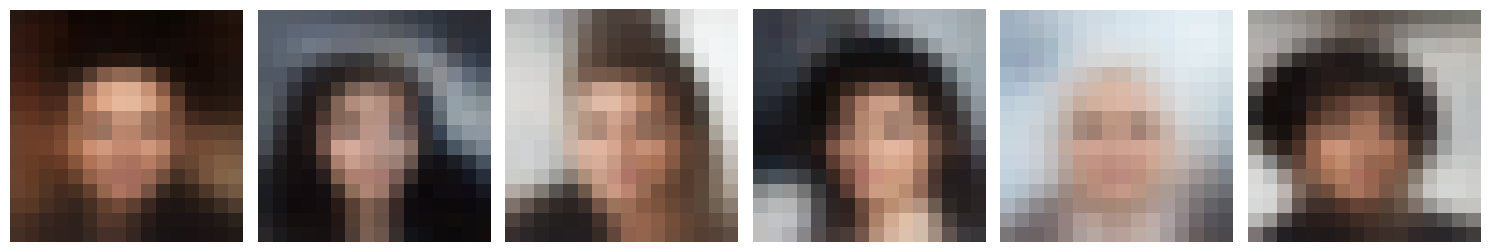

In [ ]:
if not TRAIN:
  ckpt = torch.load(SAVE_PATH, map_location=DEVICE)
  model = VanillaVAE(in_channels=3, latent_dim=ckpt['latent_dim'], hidden_dims=ckpt['hidden_dims']).to(DEVICE)
  model.load_state_dict(ckpt['model'])


model.eval()

TEMPERATURE = 1.3
z = torch.randn(6, model.latent_dim, device=DEVICE) * TEMPERATURE
with torch.no_grad():
    samples = model.decode(z).clamp(0, 1)

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for i in range(6):
    axes[i].imshow(samples[i].permute(1, 2, 0).cpu())
    axes[i].axis('off')
plt.tight_layout()
plt.show()